# Breast Cancer Classification using K-Nearest Neighbors (KNN)

## AIM
To build a machine learning model using the K-Nearest Neighbors (KNN) algorithm to classify breast cancer tumors as malignant or benign.

## Objectives
- Load the Breast Cancer Wisconsin dataset.
- Explore and preprocess the data.
- Train a KNN classifier.
- Evaluate the model using different performance metrics.
- Predict the class of breast cancer tumors.

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

In [3]:
# Load the Breast Cancer dataset
cancer = load_breast_cancer()

# Convert to a DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add the target column
df['target'] = cancer.target

# Display the first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Shape of the dataset
print("Shape of the dataset:", df.shape)

# Column names
print("\nFeature Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Class distribution
print("\nTarget Value Counts:")
print(df['target'].value_counts())

Shape of the dataset: (569, 31)

Feature Names:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-n

## Target Variable

- **0** → Malignant (Cancerous)
- **1** → Benign (Non-cancerous)

The dataset contains features computed from breast mass images, and the goal is to classify tumors into malignant or benign categories.

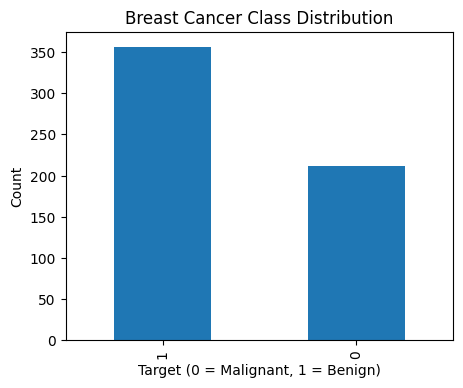

In [5]:
# Class distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
df['target'].value_counts().plot(kind='bar')
plt.title("Breast Cancer Class Distribution")
plt.xlabel("Target (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

In [6]:
# Features and target
X = df.drop('target', axis=1)
y = df['target']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [10]:
# Predict on test data
y_pred = knn.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[1 0 0 1 1 0 0 0 0 1]


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315

Confusion Matrix:
[[40  3]
 [ 3 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



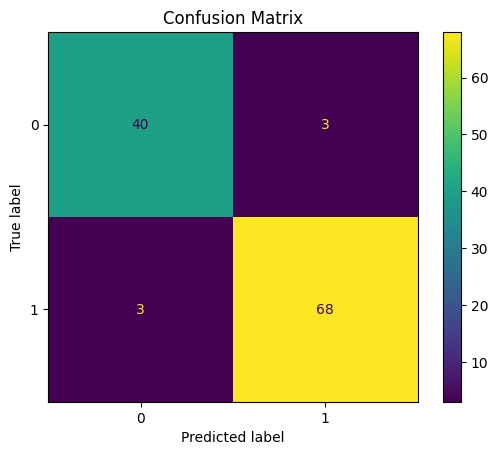

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [13]:
# Predict the first test sample
sample = X_test[0].reshape(1, -1)
prediction = knn.predict(sample)

if prediction[0] == 0:
    print("Prediction: Malignant")
else:
    print("Prediction: Benign")

Prediction: Benign


# Conclusion

A K-Nearest Neighbors (KNN) classifier was successfully implemented to classify breast cancer tumors as malignant or benign using the Breast Cancer Wisconsin dataset. The data was preprocessed by splitting it into training and testing sets and applying feature scaling. The trained model achieved good classification performance, demonstrating that KNN is an effective algorithm for this dataset. The evaluation metrics and confusion matrix indicate that the model can accurately distinguish between the two classes.